In [3]:
pip install duckdb polars

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 1.2 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.0/824.0 kB 1.1 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 1.2 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [8]:
import duckdb
import os

con = duckdb.connect()

con.execute("INSTALL httpfs; LOAD httpfs;")   # For S3 connectivity
con.execute("INSTALL iceberg; LOAD iceberg;") # For Iceberg support
con.execute("INSTALL aws; LOAD aws;")

con.execute(f"""
    CREATE SECRET minio_storage (
        TYPE s3,
        KEY_ID {os.environ.get('AWS_ACCESS_KEY_ID')},
        SECRET {os.environ.get('AWS_SECRET_ACCESS_KEY')},
        REGION 'us-east-1',
        ENDPOINT 'minio.platform:9000',
        URL_STYLE 'path',
        USE_SSL false
    );
""")
con.execute("SET unsafe_enable_version_guessing = true;")

In [48]:
con.sql("""
     WITH dim_tag AS (
        SELECT
            12.0 AS mag_percentage,
            1.2 AS color_percentage,
            'WD' AS tag
        UNION
        SELECT
            6.0 AS mag_percentage,
            1.0 AS color_percentage,
            'RGB' as tag
        UNION
        SELECT
            0.0 AS mag_percentage,
            3.0 AS color_percentage,
            'MS' as tag
    )
    SELECT * FROM dim_tag;
""")

┌────────────────┬──────────────────┬─────────┐
│ mag_percentage │ color_percentage │   tag   │
│  decimal(3,1)  │   decimal(2,1)   │ varchar │
├────────────────┼──────────────────┼─────────┤
│            6.0 │              1.0 │ RGB     │
│            0.0 │              3.0 │ MS      │
│           12.0 │              1.2 │ WD      │
└────────────────┴──────────────────┴─────────┘

In [59]:
import polars as pl

df = con.sql("""
    WITH base AS (
        SELECT 
            bp_rp,
            absolute_mag_g
        FROM iceberg_scan('s3://gaia-source/silver/gaia_main_source') 
        WHERE bp_rp IS NOT NULL
    ),
    calculate_bin_colors AS (
        SELECT 
            (ROUND(bp_rp / 0.05) * 0.05) AS bin_color,
            (ROUND(absolute_mag_g / 0.1) * 0.1) AS bin_mag,
            COUNT(*) AS star_density
        FROM base
        GROUP BY 1, 2
        ORDER BY 3 DESC
    )
    SELECT 
        bin_color,
        bin_mag,
        star_density,
        CASE
            WHEN bin_mag > 12.0 AND bin_color < 1.2 THEN 'WD'
            WHEN bin_mag < 6.0 AND bin_color > 1.0 THEN 'RGB'
            WHEN bin_mag > 0.0 AND bin_color < 3.0 THEN 'MS'
            ELSE 'Unclassified'
        END AS stellar_population_tag
    FROM calculate_bin_colors;
""").pl()

In [64]:
df = df.filter(pl.col("stellar_population_tag") != 'Unclassified')

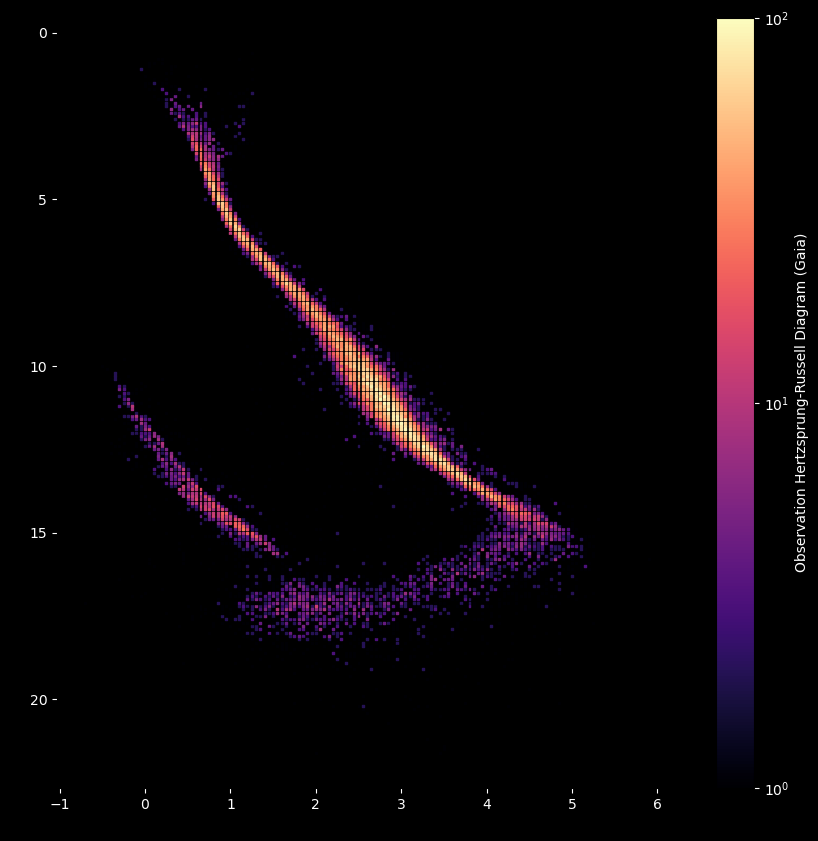

In [67]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

color = result["bin_color"].to_numpy()
mag = result["bin_mag"].to_numpy()
density = result["star_density"].to_numpy()

plt.figure(figsize=(10, 10), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

scatter = plt.scatter(
    color,
    mag,
    c=density,
    cmap='magma',
    s=2,
    norm=LogNorm(vmin=density.min(), vmax=density.max()),
    marker='s'
)

ax.invert_yaxis()

ax.set_xlabel("Color Index (BP - RP)")
ax.set_ylabel("Absolute Magnitude (MG)")
ax.tick_params(colors='white')

cbar = plt.colorbar(scatter)
cbar.set_label("Observation Hertzsprung-Russell Diagram (Gaia)", color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.show()